# Project 02 — Pretrained YOLO Object Detection

## 1. Pretrained YOLO와 Object Detection

Image classification은 하나의 image에 대해 하나의 class를 예측한다.

$$
x \rightarrow \text{class}
$$

반면 object detection은 하나의 image 안에 존재하는 여러 object의 **class와 위치를 동시에 예측**한다.

각 detection은 크게 다음 정보로 구성된다.

$$
(\text{Bounding Box},\text{Class},\text{Confidence})
$$

### Bounding Box

Bounding box는 image 안에서 object가 위치한 영역을 나타낸다.

이번 프로젝트에서는 다음과 같은 `xyxy` representation을 사용한다.

$$
(x_1,y_1,x_2,y_2)
$$

여기서 $(x_1,y_1)$은 bounding box의 왼쪽 위 좌표이고, $(x_2,y_2)$는 오른쪽 아래 좌표이다.

### Class

각 bounding box에는 해당 object가 어떤 category에 속하는지를 나타내는 class prediction이 존재한다.

Pretrained YOLO는 학습에 사용된 dataset의 class에 대해 object category를 예측한다.

### Confidence

각 detection에는 prediction의 confidence score가 함께 출력된다.

예를 들어

$$
\text{dog},\quad 0.91
$$

은 해당 bounding box를 dog로 예측했으며 confidence score가 $0.91$임을 의미한다.

Confidence threshold를 높이면 confidence가 낮은 detection은 제거되고 더 확실한 prediction만 남게 된다.

이번 프로젝트에서는 YOLO architecture를 직접 구현하거나 학습하지 않는다. 대신 pretrained YOLO model을 사용하여 실제 object detection inference pipeline과 output structure를 확인한다.

$$
\text{Image}
\rightarrow
\text{Pretrained YOLO}
\rightarrow
\text{Bounding Boxes + Classes + Confidence Scores}
$$1

In [1]:
!pip install ultralytics


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
print(np.__version__)

from ultralytics import YOLO

model = YOLO("yolo26n.pt")

print("YOLO model loaded successfully.")

2.4.6
YOLO model loaded successfully.


# 2. 한 이미지에서 YOLO Inference

Pretrained YOLO model에 image를 입력하여 object detection을 수행한다.

Image classification에서는 하나의 image에 대해 고정된 수의 class logit을 출력하지만, object detection에서는 image에서 검출된 object 수에 따라 여러 개의 detection이 출력된다.

$$
x
\rightarrow
\text{YOLO}
\rightarrow
\{\text{Detection}_1,\ldots,\text{Detection}_N\}
$$

각 detection은 다음 세 가지 주요 정보로 구성된다.

$$
(\text{Bounding Box},\text{Class},\text{Confidence})
$$

Ultralytics YOLO의 inference 결과는 `Results` object로 반환된다.

한 image의 detection 결과에서 `boxes` object를 통해 다음 정보를 확인할 수 있다.

- `boxes.xyxy`: bounding box 좌표
- `boxes.conf`: confidence score
- `boxes.cls`: predicted class index

Bounding box는

$$
(x_1,y_1,x_2,y_2)
$$

형태로 표현된다.

여기서 $(x_1,y_1)$은 bounding box의 왼쪽 위 좌표이고, $(x_2,y_2)$는 오른쪽 아래 좌표이다.

예를 들어 $N$개의 object가 검출되었다면 bounding box tensor의 shape는

$$
[N,4]
$$

가 된다.

Class index는 model이 가지고 있는 class-name mapping을 이용하여 실제 class name으로 변환할 수 있다.

In [3]:
from ultralytics.utils import ASSETS

image_path = ASSETS / "bus.jpg"
bus_result = model(
    image_path,
    verbose=False
)[0]

print("Detections:", len(bus_result.boxes))

Detections: 5


In [4]:
results = model(image_path)

result = results[0]


image 1/1 /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/ultralytics/assets/bus.jpg: 640x480 4 persons, 1 bus, 48.1ms
Speed: 1.3ms preprocess, 48.1ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 480)


In [5]:
model = YOLO("yolo26n.pt")

image_path = ASSETS / "bus.jpg"

bus_result = model(
    image_path,
    verbose=False
)[0]

print("Detections:", len(bus_result.boxes))

Detections: 5


In [6]:
print(bus_result.boxes.xyxy)

tensor([[2.2242e+02, 4.0495e+02, 3.4539e+02, 8.6152e+02],
        [0.0000e+00, 2.2938e+02, 8.0602e+02, 7.5681e+02],
        [4.7693e+01, 3.9927e+02, 2.3920e+02, 9.0300e+02],
        [6.7069e+02, 3.9153e+02, 8.0981e+02, 8.7907e+02],
        [1.2750e-01, 5.5671e+02, 6.0031e+01, 8.7012e+02]])


In [7]:
print(bus_result.boxes.conf)

tensor([0.9134, 0.9124, 0.9052, 0.8703, 0.6280])


In [8]:
print(bus_result.boxes.cls)

tensor([0., 5., 0., 0., 0.])


In [9]:
print("Bounding boxes shape:", bus_result.boxes.xyxy.shape)
print("Confidence shape:", bus_result.boxes.conf.shape)
print("Class shape:", bus_result.boxes.cls.shape)

Bounding boxes shape: torch.Size([5, 4])
Confidence shape: torch.Size([5])
Class shape: torch.Size([5])


In [10]:
print(model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [11]:
annotated = bus_result.plot()

# 3. Detection Output 해석과 시각화

YOLO는 하나의 image에서 검출된 각 object에 대해 bounding box, confidence score, class index를 반환한다.

$N$개의 object가 검출되었다면 주요 output은 다음과 같다.

$$
\text{xyxy}\in\mathbb{R}^{N\times4}
$$

$$
\text{conf}\in\mathbb{R}^{N}
$$

$$
\text{cls}\in\mathbb{R}^{N}
$$

같은 index에 위치한 값들은 하나의 detection을 의미한다.

예를 들어 detection $i$는 다음과 같이 표현할 수 있다.

$$
D_i=
(x_1,y_1,x_2,y_2,c,k)
$$

여기서

- $(x_1,y_1,x_2,y_2)$는 bounding box
- $c$는 confidence score
- $k$는 predicted class index

이다.

이번 image에서는 총 5개의 object가 검출되었다.

$$
4\text{ persons}+1\text{ bus}
$$

YOLO의 `Results.plot()`을 이용하면 bounding box, class name, confidence score를 original image 위에 직접 시각화할 수 있다.

In [12]:
boxes = bus_result.boxes

for i in range(len(boxes)):
    bbox = boxes.xyxy[i]
    confidence = boxes.conf[i]
    class_id = int(boxes.cls[i])
    class_name = model.names[class_id]

    print(f"Detection {i + 1}")
    print(f"Class      : {class_name}")
    print(f"Confidence : {confidence.item():.4f}")
    print(
        f"BBox       : "
        f"({bbox[0].item():.1f}, {bbox[1].item():.1f}, "
        f"{bbox[2].item():.1f}, {bbox[3].item():.1f})"
    )
    print()

Detection 1
Class      : person
Confidence : 0.9134
BBox       : (222.4, 405.0, 345.4, 861.5)

Detection 2
Class      : bus
Confidence : 0.9124
BBox       : (0.0, 229.4, 806.0, 756.8)

Detection 3
Class      : person
Confidence : 0.9052
BBox       : (47.7, 399.3, 239.2, 903.0)

Detection 4
Class      : person
Confidence : 0.8703
BBox       : (670.7, 391.5, 809.8, 879.1)

Detection 5
Class      : person
Confidence : 0.6280
BBox       : (0.1, 556.7, 60.0, 870.1)



In [13]:
print(bus_result.boxes.data)

tensor([[2.2242e+02, 4.0495e+02, 3.4539e+02, 8.6152e+02, 9.1339e-01, 0.0000e+00],
        [0.0000e+00, 2.2938e+02, 8.0602e+02, 7.5681e+02, 9.1245e-01, 5.0000e+00],
        [4.7693e+01, 3.9927e+02, 2.3920e+02, 9.0300e+02, 9.0519e-01, 0.0000e+00],
        [6.7069e+02, 3.9153e+02, 8.0981e+02, 8.7907e+02, 8.7034e-01, 0.0000e+00],
        [1.2750e-01, 5.5671e+02, 6.0031e+01, 8.7012e+02, 6.2795e-01, 0.0000e+00]])


In [14]:
import matplotlib.pyplot as plt
import cv2

annotated_image = bus_result.plot()

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [15]:
print("Original image shape :", result.orig_shape)
print("Inference box coords :", result.boxes.xyxy.shape)

Original image shape : (1080, 810)
Inference box coords : torch.Size([5, 4])


# 4. Bounding Box 좌표 표현과 Object Crop

Object detection에서는 하나의 bounding box를 여러 coordinate representation으로 표현할 수 있다.

### xyxy

`xyxy`는 bounding box의 왼쪽 위와 오른쪽 아래 좌표를 사용한다.

$$
(x_1,y_1,x_2,y_2)
$$

여기서 $(x_1,y_1)$은 왼쪽 위 좌표이고 $(x_2,y_2)$는 오른쪽 아래 좌표이다.

### xywh

`xywh`는 bounding box의 중심 좌표와 width, height를 사용한다.

$$
(x_c,y_c,w,h)
$$

두 표현은 다음 관계를 가진다.

$$
x_c=\frac{x_1+x_2}{2}
$$

$$
y_c=\frac{y_1+y_2}{2}
$$

$$
w=x_2-x_1
$$

$$
h=y_2-y_1
$$

### Normalized Coordinates

`xyxyn`과 `xywhn`은 bounding box coordinate를 original image 크기로 나눈 normalized representation이다.

예를 들어 image width가 $W$라면

$$
x_{\text{norm}}=\frac{x}{W}
$$

로 계산한다.

Normalized coordinate는 image resolution과 무관하게 bounding box를 $[0,1]$ 범위에서 표현할 수 있다.

Ultralytics의 `Boxes` object에서는 다음 representation을 제공한다.

- `boxes.xyxy`
- `boxes.xywh`
- `boxes.xyxyn`
- `boxes.xywhn`

Detection 결과의 bounding box를 이용하면 original image에서 해당 object 영역만 직접 crop할 수도 있다.

$$
\text{Detection}
\rightarrow
\text{Bounding Box}
\rightarrow
\text{Object Crop}
$$

In [16]:
box = result.boxes

print("xyxy  :", box.xyxy[0])
print("xywh  :", box.xywh[0])
print("xyxyn :", box.xyxyn[0])
print("xywhn :", box.xywhn[0])

xyxy  : tensor([222.4225, 404.9516, 345.3937, 861.5190])
xywh  : tensor([283.9081, 633.2353, 122.9712, 456.5674])
xyxyn : tensor([0.2746, 0.3750, 0.4264, 0.7977])
xywhn : tensor([0.3505, 0.5863, 0.1518, 0.4227])


In [17]:
print("Original image shape:", result.orig_shape)

Original image shape: (1080, 810)


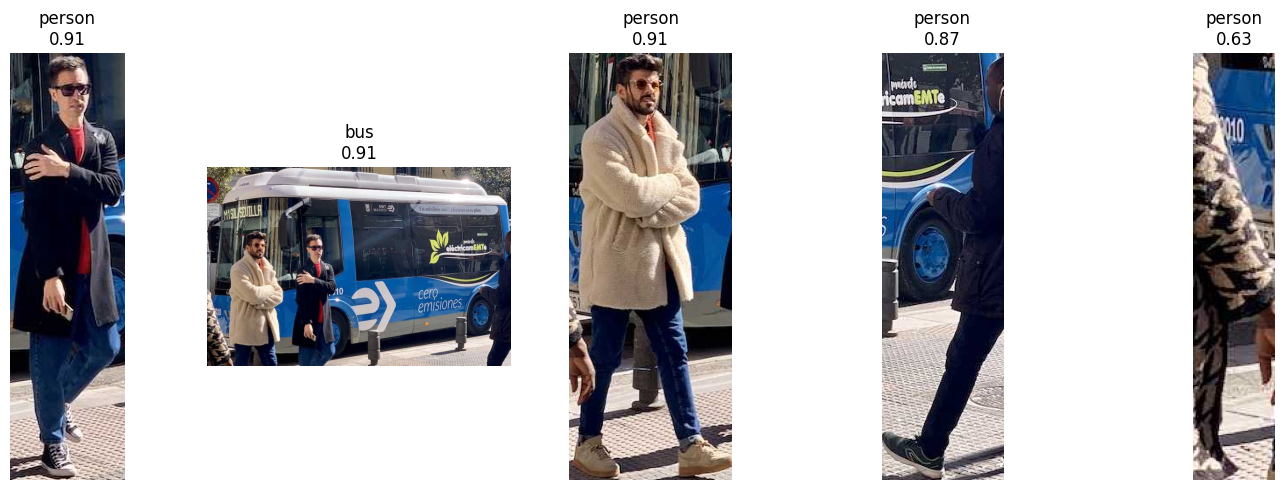

In [18]:
original = bus_result.orig_img

fig, axes = plt.subplots(
    1,
    len(bus_result.boxes),
    figsize=(15, 5)
)

for i, bbox in enumerate(bus_result.boxes.xyxy):

    x1, y1, x2, y2 = bbox.int().tolist()

    crop = original[y1:y2, x1:x2]

    class_id = int(bus_result.boxes.cls[i])
    class_name = model.names[class_id]
    confidence = bus_result.boxes.conf[i].item()

    axes[i].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    axes[i].set_title(
        f"{class_name}\n{confidence:.2f}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()



# 5. Confidence Threshold 실험

Object detector는 모든 prediction을 최종 detection으로 사용하지 않는다.

각 prediction에는 confidence score가 존재하며, 설정한 confidence threshold보다 낮은 prediction은 제거한다.

Confidence score를 $c$, threshold를 $t$라고 하면 최종 detection은

$$
c \ge t
$$

를 만족하는 prediction만 남는다.

Confidence threshold를 낮추면 더 많은 object를 검출할 수 있지만 false positive가 증가할 가능성이 있다.

반대로 threshold를 높이면 더 확실한 prediction만 남지만 실제 object를 놓치는 false negative가 증가할 수 있다.

따라서 confidence threshold는 detection system의 목적에 따라 조절해야 하는 hyperparameter이다.

이번 실험에서는 동일한 image에 대해 다음 threshold를 비교한다.

$$
t \in \{0.1,\;0.25,\;0.5,\;0.8\}
$$

각 threshold에서 detection의 수와 시각화 결과가 어떻게 달라지는지 확인한다.

In [19]:
thresholds = [0.1, 0.25, 0.5, 0.8]

In [20]:
threshold_results = []

for threshold in thresholds:
    result_t = model(
        image_path,
        conf=threshold,
        verbose=False
    )[0]

    threshold_results.append(result_t)

    print(
        f"conf={threshold:.2f} | "
        f"detections={len(result_t.boxes)}"
    )

conf=0.10 | detections=7
conf=0.25 | detections=5
conf=0.50 | detections=5
conf=0.80 | detections=4


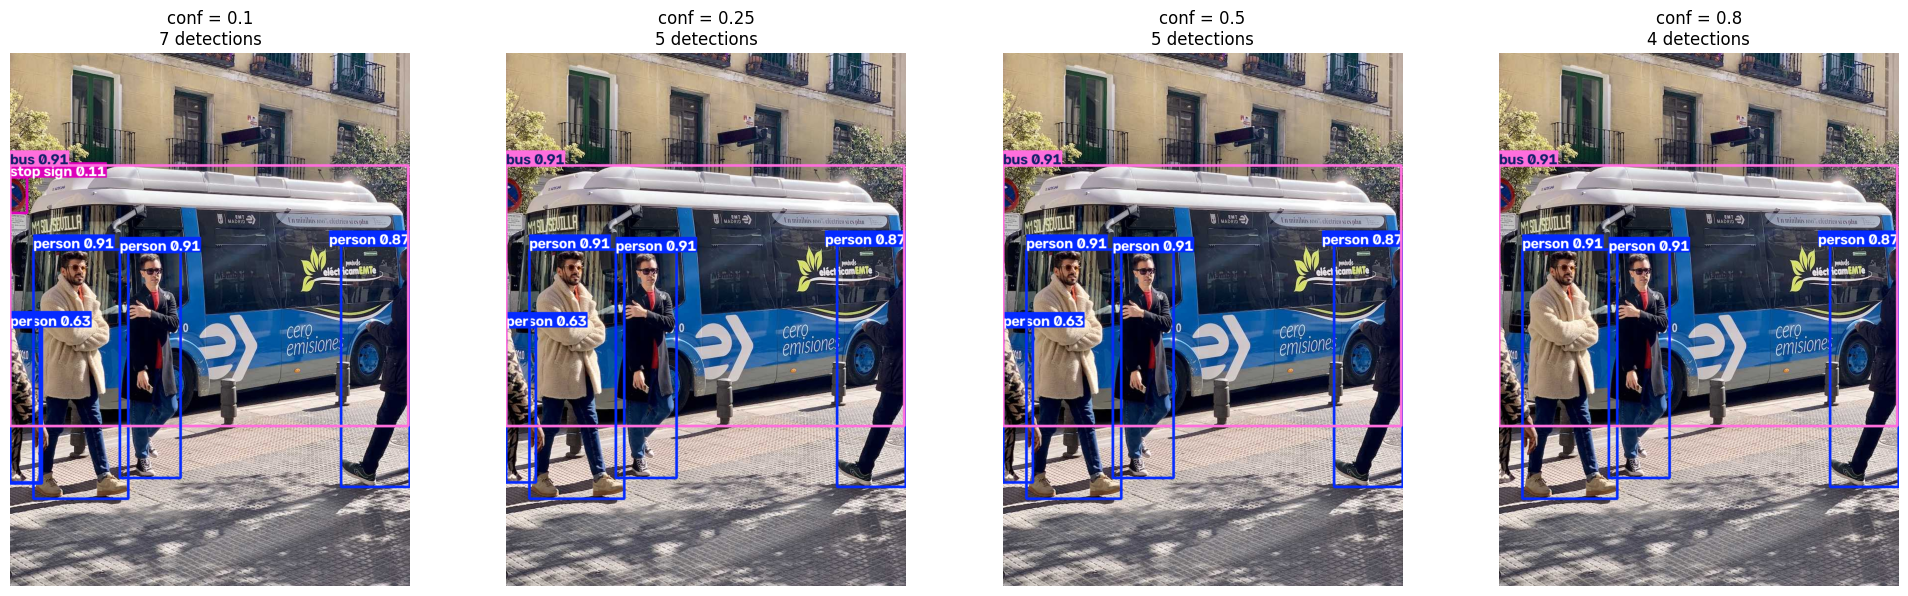

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for ax, threshold, result_t in zip(
    axes,
    thresholds,
    threshold_results
):
    annotated = result_t.plot()

    ax.imshow(
        cv2.cvtColor(
            annotated,
            cv2.COLOR_BGR2RGB
        )
    )

    ax.set_title(
        f"conf = {threshold}\n"
        f"{len(result_t.boxes)} detections"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [22]:
from collections import Counter

for threshold, result_t in zip(
    thresholds,
    threshold_results
):
    class_names = [
        model.names[int(class_id)]
        for class_id in result_t.boxes.cls
    ]

    counts = Counter(class_names)

    print(
        f"conf={threshold:.2f} -> {dict(counts)}"
    )

conf=0.10 -> {'person': 5, 'bus': 1, 'stop sign': 1}
conf=0.25 -> {'person': 4, 'bus': 1}
conf=0.50 -> {'person': 4, 'bus': 1}
conf=0.80 -> {'person': 3, 'bus': 1}


# 6. IoU, NMS, and NMS-Free Detection

### Intersection over Union

IoU는 두 bounding box가 얼마나 겹치는지를 측정하는 값이다.

두 bounding box를 $A$, $B$라고 하면

$$
\operatorname{IoU}(A,B)
=
\frac{|A\cap B|}
{|A\cup B|}
$$

로 정의한다.

두 box가 전혀 겹치지 않으면

$$
IoU=0
$$

이고, 완전히 동일하면

$$
IoU=1
$$

이다.

### Non-Maximum Suppression

Traditional object detector는 하나의 object에 대해 여러 overlapping bounding box를 생성할 수 있다.

Non-Maximum Suppression(NMS)은 confidence가 가장 높은 bounding box를 먼저 선택한 뒤, 해당 box와 IoU가 높은 중복 prediction을 제거한다.

일반적인 NMS pipeline은 다음과 같다.

$$
\text{Candidate Boxes}
\rightarrow
\text{Confidence Ranking}
\rightarrow
\text{IoU-based Suppression}
\rightarrow
\text{Final Detections}
$$

### YOLO26: End-to-End NMS-Free Detection

YOLO26은 기본 inference에서 별도의 NMS post-processing을 사용하지 않는다.

Traditional YOLO:

$$
\text{Image}
\rightarrow
\text{Model}
\rightarrow
\text{Candidate Boxes}
\rightarrow
\text{NMS}
\rightarrow
\text{Final Detections}
$$

YOLO26 default inference:

$$
\text{Image}
\rightarrow
\text{Model}
\rightarrow
\text{Final Detections}
$$

YOLO26은 기본적으로 one-to-one detection head를 사용하여 중복이 억제된 final detection을 직접 출력한다.

하지만 `end2end=False`로 설정하면 traditional one-to-many prediction과 NMS pipeline을 사용할 수도 있다.

이번 실험에서는 YOLO26의 end-to-end mode와 traditional NMS mode를 직접 비교한다.

In [23]:
print("End-to-end:", model.model.end2end)

End-to-end: True


In [24]:
result_e2e = model.predict(
    image_path,
    conf=0.1,
    verbose=False
)[0]

print(
    "End-to-end detections:",
    len(result_e2e.boxes)
)

End-to-end detections: 7


In [25]:
result_nms = model.predict(
    image_path,
    conf=0.1,
    iou=0.7,
    end2end=False,
    verbose=False
)[0]

print(
    "Traditional NMS detections:",
    len(result_nms.boxes)
)

Traditional NMS detections: 7


In [26]:
from collections import Counter

def get_class_counts(result):
    names = [
        model.names[int(cls)]
        for cls in result.boxes.cls
    ]
    return Counter(names)


print(
    "End-to-end:",
    dict(get_class_counts(result_e2e))
)

print(
    "NMS:",
    dict(get_class_counts(result_nms))
)

End-to-end: {'person': 5, 'bus': 1, 'stop sign': 1}
NMS: {'person': 5, 'bus': 1, 'stop sign': 1}


In [27]:
iou_thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

nms_results = []

for threshold in iou_thresholds:

    r = model.predict(
        image_path,
        conf=0.05,
        iou=threshold,
        end2end=False,
        verbose=False
    )[0]

    nms_results.append(r)

    print(
        f"IoU={threshold:.1f} | "
        f"detections={len(r.boxes)} | "
        f"{dict(get_class_counts(r))}"
    )

IoU=0.1 | detections=10 | {'person': 5, 'bus': 1, 'stop sign': 2, 'handbag': 2}
IoU=0.3 | detections=10 | {'person': 5, 'bus': 1, 'stop sign': 2, 'handbag': 2}
IoU=0.5 | detections=10 | {'person': 5, 'bus': 1, 'stop sign': 2, 'handbag': 2}
IoU=0.7 | detections=10 | {'person': 5, 'bus': 1, 'stop sign': 2, 'handbag': 2}
IoU=0.9 | detections=10 | {'person': 5, 'bus': 1, 'stop sign': 2, 'handbag': 2}


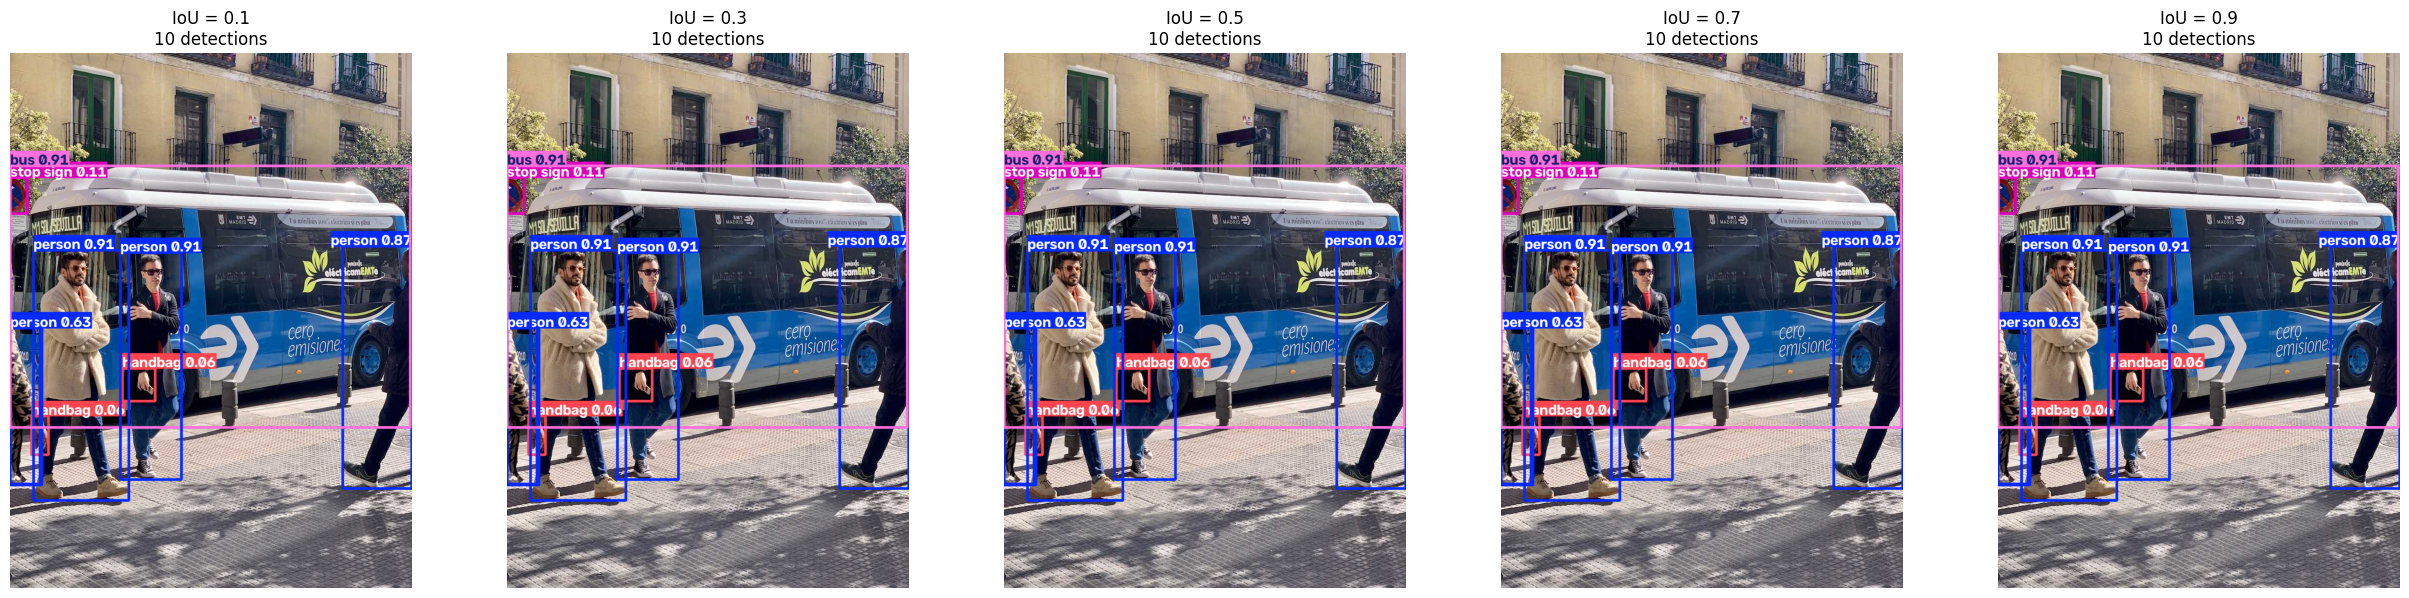

In [28]:
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for ax, threshold, r in zip(
    axes,
    iou_thresholds,
    nms_results
):

    annotated = r.plot()

    ax.imshow(
        cv2.cvtColor(
            annotated,
            cv2.COLOR_BGR2RGB
        )
    )

    ax.set_title(
        f"IoU = {threshold}\n"
        f"{len(r.boxes)} detections"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# 7. Pairwise IoU Analysis

NMS의 IoU threshold를 $0.1$에서 $0.9$까지 변경했지만 detection 결과는 변하지 않았다.

NMS threshold는 모든 bounding box의 수를 직접 조절하는 값이 아니라, 서로 겹치는 prediction을 제거할 때 사용한다.

두 bounding box $A$, $B$의 IoU는

$$
IoU(A,B)
=
\frac{|A\cap B|}
{|A\cup B|}
$$

로 정의한다.

또한 기본 NMS는 class-aware 방식으로 동작한다. 따라서 서로 다른 class의 bounding box는 spatially overlap하더라도 서로 suppression하지 않는다.

이번 실험에서는 실제 detection들의 pairwise IoU를 계산하여 NMS threshold 변화가 결과에 영향을 주지 않은 이유를 확인한다.

In [29]:
from torchvision.ops import box_iou

boxes = result_nms.boxes.xyxy

iou_matrix = box_iou(boxes, boxes)

print(iou_matrix)

tensor([[1.0000, 0.0988, 0.0529, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0988, 1.0000, 0.1511, 0.1115, 0.0278, 0.0058, 0.0301],
        [0.0529, 0.1511, 1.0000, 0.0000, 0.0347, 0.0000, 0.0483],
        [0.0000, 0.1115, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0278, 0.0347, 0.0000, 1.0000, 0.0000, 0.9109],
        [0.0000, 0.0058, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000],
        [0.0000, 0.0301, 0.0483, 0.0000, 0.9109, 0.0000, 1.0000]])


In [30]:
class_names = [
    model.names[int(cls)]
    for cls in result_nms.boxes.cls
]

for i, name in enumerate(class_names):
    print(i, name)

0 person
1 bus
2 person
3 person
4 person
5 stop sign
6 person


In [31]:
from torchvision.ops import box_iou
import torch

# Bounding boxes
boxes = result_nms.boxes.xyxy

# Pairwise IoU matrix
iou_matrix = box_iou(boxes, boxes)

# 자기 자신과의 IoU = 1인 diagonal을 제외
iou_without_diagonal = iou_matrix.clone()
iou_without_diagonal.fill_diagonal_(-1)

# 가장 큰 IoU의 위치 찾기
flat_index = torch.argmax(iou_without_diagonal)

row = flat_index // iou_matrix.shape[1]
col = flat_index % iou_matrix.shape[1]

row = row.item()
col = col.item()

# Detection 정보
class_id_1 = int(result_nms.boxes.cls[row])
class_id_2 = int(result_nms.boxes.cls[col])

class_name_1 = model.names[class_id_1]
class_name_2 = model.names[class_id_2]

confidence_1 = result_nms.boxes.conf[row].item()
confidence_2 = result_nms.boxes.conf[col].item()

max_iou = iou_matrix[row, col].item()

# 결과 출력
print(f"Detection {row}")
print(f"  Class      : {class_name_1}")
print(f"  Confidence : {confidence_1:.4f}")
print(f"  Box        : {boxes[row].tolist()}")

print()

print(f"Detection {col}")
print(f"  Class      : {class_name_2}")
print(f"  Confidence : {confidence_2:.4f}")
print(f"  Box        : {boxes[col].tolist()}")

print()

print(f"Maximum IoU : {max_iou:.4f}")

Detection 4
  Class      : person
  Confidence : 0.6280
  Box        : [0.12749719619750977, 556.705810546875, 60.031028747558594, 870.1171875]

Detection 6
  Class      : person
  Confidence : 0.1134
  Box        : [0.38540446758270264, 554.0126342773438, 64.62422180175781, 872.2066040039062]

Maximum IoU : 0.9109


In [32]:
print(iou_matrix)

tensor([[1.0000, 0.0988, 0.0529, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0988, 1.0000, 0.1511, 0.1115, 0.0278, 0.0058, 0.0301],
        [0.0529, 0.1511, 1.0000, 0.0000, 0.0347, 0.0000, 0.0483],
        [0.0000, 0.1115, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0278, 0.0347, 0.0000, 1.0000, 0.0000, 0.9109],
        [0.0000, 0.0058, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000],
        [0.0000, 0.0301, 0.0483, 0.0000, 0.9109, 0.0000, 1.0000]])


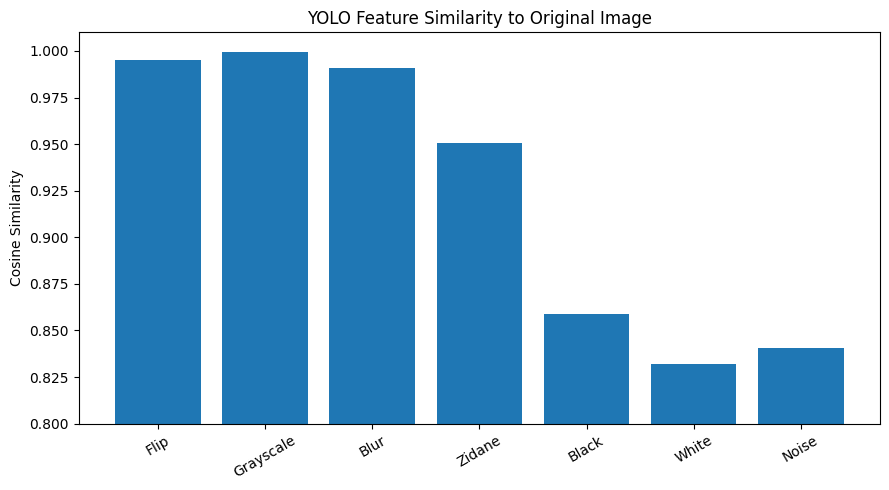

In [47]:
labels = [
    "Flip",
    "Grayscale",
    "Blur",
    "Zidane",
    "Black",
    "White",
    "Noise"
]

scores = [
    0.9952,
    0.9994,
    0.9911,
    0.9504,
    0.8590,
    0.8322,
    0.8408
]

plt.figure(figsize=(9, 5))

plt.bar(labels, scores)

plt.ylim(0.8, 1.01)
plt.ylabel("Cosine Similarity")
plt.title("YOLO Feature Similarity to Original Image")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "results/figures/embedding_similarity.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# 8. YOLO Feature Embedding

YOLO는 final detection을 출력하기 전에 image에서 high-dimensional feature representation을 추출한다.

전체 과정을 단순화하면 다음과 같이 볼 수 있다.

$$
\text{Image}
\rightarrow
\text{Feature Representation}
\rightarrow
\text{Detection}
$$

이러한 feature representation을 embedding으로 사용할 수 있다.

Ultralytics YOLO에서는 `model.embed()`을 이용하여 model 내부의 feature embedding을 추출할 수 있다.

Embedding은 class label과 같은 discrete output이 아니라 high-dimensional vector이다.

$$
z\in\mathbb{R}^{d}
$$

서로 다른 image의 embedding이 얼마나 비슷한지 비교하기 위해 cosine similarity를 사용할 수 있다.

두 embedding $a$, $b$의 cosine similarity는

$$
\operatorname{cosine}(a,b)
=
\frac{a^\top b}
{\|a\|\|b\|}
$$

로 정의한다.

Cosine similarity가 클수록 두 embedding의 방향이 비슷하다는 의미이다.

이번 실험에서는 서로 다른 image의 YOLO embedding을 추출하고 feature space에서의 similarity를 비교한다.

In [33]:
embeddings = model.embed(
    image_path,
    verbose=False
)

embedding = embeddings[0]

print(type(embedding))
print("Embedding shape:", embedding.shape)
print(embedding[:20])

<class 'torch.Tensor'>
Embedding shape: torch.Size([256])
tensor([ 0.0731,  1.4118, -0.2258, -0.0484,  0.2280, -0.1735,  0.2721,  0.7107, -0.0506, -0.2039, -0.1723, -0.1477,  0.6205, -0.1978,  0.0055,  0.0414, -0.1700,  0.0494, -0.0094, -0.0457])


In [34]:
print("Mean :", embedding.mean().item())
print("Std  :", embedding.std().item())
print("Min  :", embedding.min().item())
print("Max  :", embedding.max().item())
print("Norm :", embedding.norm().item())

Mean : 0.1222599670290947
Std  : 0.44586625695228577
Min  : -0.24533912539482117
Max  : 2.8596322536468506
Norm : 7.383747577667236


In [35]:
import torch.nn.functional as F

similarity = F.cosine_similarity(
    embedding.unsqueeze(0),
    embedding.unsqueeze(0)
)

print(similarity.item())

1.0


# 9. Image Transformation과 Feature Similarity

YOLO 내부의 feature embedding이 image transformation에 어떻게 반응하는지 확인한다.

Original image에서 다음 transformation을 생성한다.

- Horizontal Flip
- Grayscale
- Gaussian Blur
- Completely Different Image

각 image에서 embedding을 추출한 뒤 original image와 cosine similarity를 계산한다.

두 embedding $a$, $b$의 cosine similarity는

$$
\operatorname{cosine}(a,b)
=
\frac{a^\top b}
{\|a\|\|b\|}
$$

이다.

이번 실험의 목적은 pixel-level 변화와 feature-level 변화가 반드시 동일하지 않다는 점을 확인하는 것이다.

$$
\text{Pixel Similarity}
\neq
\text{Feature Similarity}
$$

단, YOLO embedding은 image similarity만을 목적으로 학습된 representation은 아니므로 cosine similarity를 절대적인 semantic similarity score로 해석하지 않는다.

In [36]:
import cv2
from ultralytics.utils import ASSETS

original = cv2.imread(str(image_path))

# 1. Horizontal flip
flipped = cv2.flip(original, 1)

# 2. Grayscale
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
gray = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# 3. Gaussian blur
blurred = cv2.GaussianBlur(
    original,
    (31, 31),
    0
)

# 4. Completely different image
zidane_path = ASSETS / "zidane.jpg"
different = cv2.imread(str(zidane_path))

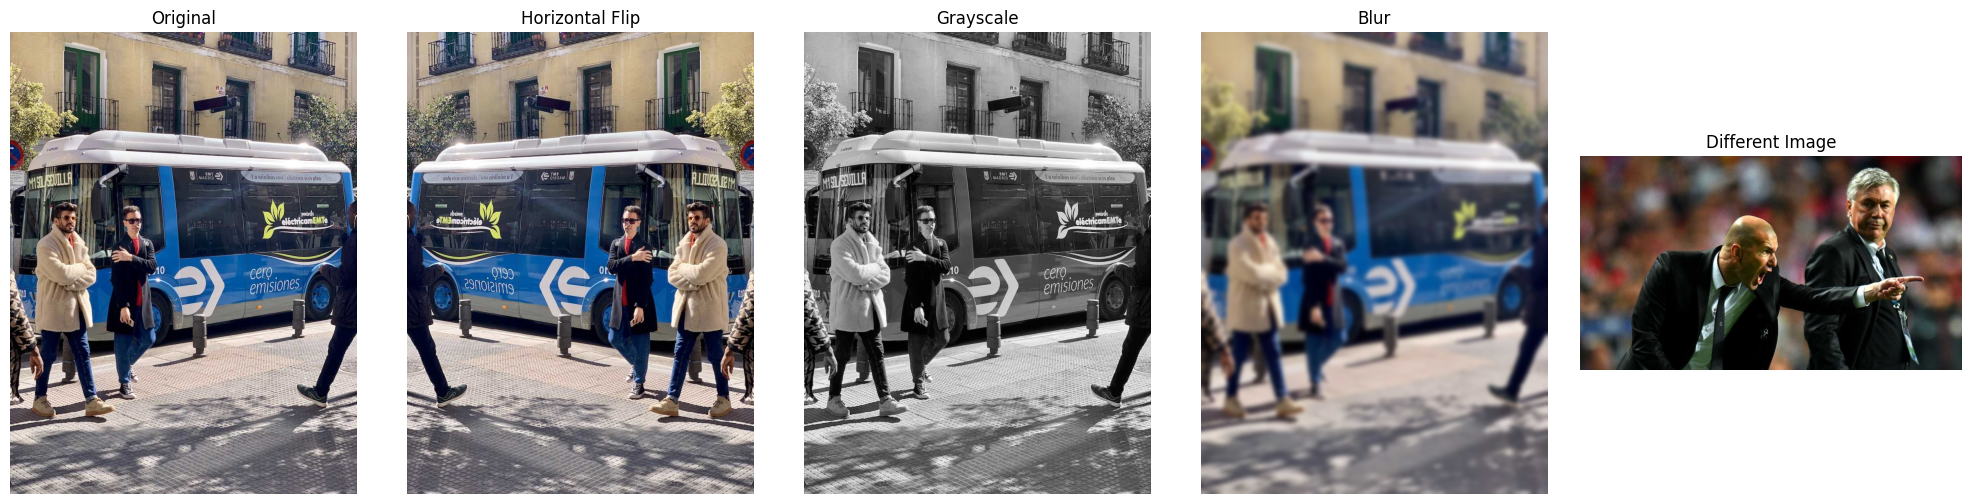

In [37]:
import matplotlib.pyplot as plt

images = [
    original,
    flipped,
    gray,
    blurred,
    different
]

titles = [
    "Original",
    "Horizontal Flip",
    "Grayscale",
    "Blur",
    "Different Image"
]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, image, title in zip(axes, images, titles):
    ax.imshow(
        cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [38]:
def get_embedding(image):
    return model.embed(
        image,
        verbose=False
    )[0]


emb_original = get_embedding(original)
emb_flipped = get_embedding(flipped)
emb_gray = get_embedding(gray)
emb_blurred = get_embedding(blurred)
emb_different = get_embedding(different)

In [39]:
import torch.nn.functional as F

def cosine_similarity(a, b):
    return F.cosine_similarity(
        a,
        b,
        dim=0
    ).item()


similarities = {
    "Original vs Original":
        cosine_similarity(emb_original, emb_original),

    "Original vs Flip":
        cosine_similarity(emb_original, emb_flipped),

    "Original vs Grayscale":
        cosine_similarity(emb_original, emb_gray),

    "Original vs Blur":
        cosine_similarity(emb_original, emb_blurred),

    "Original vs Different":
        cosine_similarity(emb_original, emb_different),
}

for name, score in similarities.items():
    print(f"{name:25s}: {score:.4f}")

Original vs Original     : 1.0000
Original vs Flip         : 0.9952
Original vs Grayscale    : 0.9994
Original vs Blur         : 0.9911
Original vs Different    : 0.9504


In [40]:
import numpy as np

# 완전히 검은 image
black = np.zeros_like(original)

# 완전히 흰 image
white = np.ones_like(original) * 255

# random noise
noise = np.random.randint(
    0, 256,
    original.shape,
    dtype=np.uint8
)

emb_black = get_embedding(black)
emb_white = get_embedding(white)
emb_noise = get_embedding(noise)

test_similarities = {
    "Original vs Flip":
        cosine_similarity(emb_original, emb_flipped),

    "Original vs Grayscale":
        cosine_similarity(emb_original, emb_gray),

    "Original vs Blur":
        cosine_similarity(emb_original, emb_blurred),

    "Original vs Zidane":
        cosine_similarity(emb_original, emb_different),

    "Original vs Black":
        cosine_similarity(emb_original, emb_black),

    "Original vs White":
        cosine_similarity(emb_original, emb_white),

    "Original vs Noise":
        cosine_similarity(emb_original, emb_noise),
}

for name, score in test_similarities.items():
    print(f"{name:25s}: {score:.4f}")

Original vs Flip         : 0.9952
Original vs Grayscale    : 0.9994
Original vs Blur         : 0.9911
Original vs Zidane       : 0.9504
Original vs Black        : 0.8590
Original vs White        : 0.8322
Original vs Noise        : 0.8355


# Observation

YOLO embedding은 horizontal flip, grayscale, blur와 같은 image transformation에 매우 안정적인 모습을 보였다.

Original image와 transformed image의 cosine similarity는 모두 $0.99$ 이상이었다.

반면 completely different image에서는 similarity가 약 $0.95$로 감소했고, black image, white image, random noise에서는 약 $0.83\sim0.86$까지 감소했다.

그러나 unrelated input에서도 cosine similarity가 상당히 높게 나타났기 때문에 YOLO의 raw embedding에서 cosine similarity의 절대값을 semantic similarity로 직접 해석하는 것은 적절하지 않다.

이 실험을 통해 feature representation을 추출할 수 있다는 것과 해당 feature space의 distance가 특정 목적에 의미 있게 calibrated되어 있다는 것은 별개의 문제임을 확인했다.

# 10. Multi-Object Tracking

Object detection은 각 image 또는 video frame에서 object의 class와 위치를 예측한다.

$$
\text{Detection}
=
(\text{Bounding Box},\text{Class},\text{Confidence})
$$

하지만 각 frame을 독립적으로 처리하면 서로 다른 frame에서 검출된 object가 동일한 object인지 알 수 없다.

Multi-object tracking은 detection에 track ID를 추가하여 시간에 따라 동일한 object를 추적한다.

$$
\text{Tracking Result}
=
(\text{Bounding Box},\text{Class},\text{Confidence},\text{Track ID})
$$

전체 pipeline은 다음과 같이 볼 수 있다.

$$
\text{Video Frame}
\rightarrow
\text{Object Detection}
\rightarrow
\text{Data Association}
\rightarrow
\text{Track ID}
$$

예를 들어 동일한 사람이 여러 frame에서 검출되면 tracker는 가능한 경우 같은 ID를 유지한다.

$$
\text{Person ID 3}
\rightarrow
\text{Person ID 3}
\rightarrow
\text{Person ID 3}
$$

이번 실험에서는 YOLO26 detector와 ByteTrack을 결합하여 video의 object를 추적한다.

In [41]:
cap = cv2.VideoCapture("/Users/moonsong/Desktop/학업/cs229/프로젝트/03_YOLO/video/mixkit-young-bearded-man-walking-down-the-street-4888-hd-ready.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    "tracking_result.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

tracking_model = YOLO("yolo26n.pt")

while cap.isOpened():

    success, frame = cap.read()

    if not success:
        break

    result = tracking_model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        verbose=False
    )[0]

    annotated_frame = result.plot()

    writer.write(annotated_frame)

cap.release()
writer.release()

print("Saved: tracking_result.mp4")

Saved: tracking_result.mp4


## 11. Track History와 Trajectory Visualization

Object tracking에서는 각 frame에서 동일한 object에 동일한 track ID를 부여한다.

각 bounding box의 중심 좌표를 시간에 따라 저장하면 object의 이동 경로를 구성할 수 있다.

Bounding box가

$$
(x_1,y_1,x_2,y_2)
$$

로 주어졌을 때 중심 좌표는

$$
x_c=\frac{x_1+x_2}{2}
$$

$$
y_c=\frac{y_1+y_2}{2}
$$

이다.

Track ID가 $k$인 object의 위치를 frame마다 저장하면

$$
p_1^{(k)},p_2^{(k)},\ldots,p_T^{(k)}
$$

형태의 track history를 얻을 수 있다.

이 좌표들을 시간 순서대로 연결하면 object의 trajectory를 시각화할 수 있다.

이번 실험에서는 각 Track ID의 최근 위치를 저장하고 video frame 위에 trajectory를 선으로 그린다.

In [42]:
from collections import defaultdict

track_history = defaultdict(list)

In [43]:
import cv2
import numpy as np
from ultralytics import YOLO
from collections import defaultdict

video_path = "/Users/moonsong/Desktop/학업/cs229/프로젝트/03_YOLO/video/mixkit-young-bearded-man-walking-down-the-street-4888-hd-ready.mp4"

tracking_model = YOLO("yolo26n.pt")

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    "tracking_trajectory.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

track_history = defaultdict(list)

In [44]:
from collections import defaultdict
import cv2
import numpy as np
from ultralytics import YOLO

video_path = "/Users/moonsong/Desktop/학업/cs229/프로젝트/03_YOLO/video/mixkit-young-bearded-man-walking-down-the-street-4888-hd-ready.mp4"

tracking_model = YOLO("yolo26n.pt")

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    "tracking_trajectory.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

track_history = defaultdict(list)

while cap.isOpened():

    success, frame = cap.read()

    if not success:
        break

    result = tracking_model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        verbose=False
    )[0]

    annotated_frame = result.plot()

    if result.boxes.is_track:

        boxes = result.boxes.xywh.cpu()
        track_ids = result.boxes.id.int().cpu().tolist()

        for box, track_id in zip(boxes, track_ids):

            x, y, w, h = box

            center = (
                float(x),
                float(y)
            )

            track_history[track_id].append(center)

            if len(track_history[track_id]) > 60:
                track_history[track_id].pop(0)

            points = np.array(
                track_history[track_id],
                dtype=np.int32
            ).reshape((-1, 1, 2))

            cv2.polylines(
                annotated_frame,
                [points],
                isClosed=False,
                color=(255, 255, 255),
                thickness=3
            )

    writer.write(annotated_frame)

cap.release()
writer.release()

print("Saved: tracking_trajectory.mp4")

Saved: tracking_trajectory.mp4


# 12. Line Crossing Object Counter

Object tracking 결과를 이용하여 특정 virtual line을 통과하는 object의 수를 계산한다.

각 tracked object의 bounding box center를

$$
p_t=(x_t,y_t)
$$

라고 하자.

Horizontal counting line의 위치를

$$
y=y_{\text{line}}
$$

으로 정의할 수 있다.

Object의 이전 위치와 현재 위치가 line의 서로 다른 쪽에 존재하면 해당 object가 line을 crossing했다고 판단할 수 있다.

예를 들어

$$
y_{t-1}<y_{\text{line}}
$$

이고

$$
y_t\ge y_{\text{line}}
$$

이면 object가 위쪽에서 아래쪽으로 line을 통과한 것이다.

반대로

$$
y_{t-1}>y_{\text{line}}
$$

이고

$$
y_t\le y_{\text{line}}
$$

이면 아래쪽에서 위쪽으로 crossing한 것이다.

각 object에는 persistent track ID가 존재하므로 동일한 object가 여러 frame에 등장하더라도 crossing event만 count할 수 있다.

$$
\text{Detection}
\rightarrow
\text{Tracking}
\rightarrow
\text{Trajectory}
\rightarrow
\text{Line Crossing Count}
$$

In [45]:
import cv2
from ultralytics import YOLO

video_path = "/Users/moonsong/Desktop/학업/cs229/프로젝트/03_YOLO/video/mixkit-cars-driving-by-on-road-2022-hd-ready.mp4"

tracking_model = YOLO("yolo26n.pt")

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    "line_counter.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

# counting line
line_y = height // 2

# previous position of each track
previous_y = {}

# IDs already counted
counted_down = set()
counted_up = set()

down_count = 0
up_count = 0

while cap.isOpened():

    success, frame = cap.read()

    if not success:
        break

    result = tracking_model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        verbose=False
    )[0]

    annotated_frame = result.plot()

    # counting line
    cv2.line(
        annotated_frame,
        (0, line_y),
        (width, line_y),
        (255, 255, 255),
        3
    )

    if result.boxes.is_track:

        boxes = result.boxes.xywh.cpu()
        track_ids = result.boxes.id.int().cpu().tolist()
        class_ids = result.boxes.cls.int().cpu().tolist()

        for box, track_id, class_id in zip(
            boxes,
            track_ids,
            class_ids
        ):

            x, y, w, h = box

            current_y = float(y)

            # 이전 위치가 존재한다면 crossing 검사
            if track_id in previous_y:

                prev_y = previous_y[track_id]

                # 위 -> 아래
                if (
                    prev_y < line_y
                    and current_y >= line_y
                    and track_id not in counted_down
                ):
                    down_count += 1
                    counted_down.add(track_id)

                # 아래 -> 위
                elif (
                    prev_y > line_y
                    and current_y <= line_y
                    and track_id not in counted_up
                ):
                    up_count += 1
                    counted_up.add(track_id)

            previous_y[track_id] = current_y

    # count 표시
    cv2.putText(
        annotated_frame,
        f"DOWN: {down_count}",
        (30, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (255, 255, 255),
        3
    )

    cv2.putText(
        annotated_frame,
        f"UP: {up_count}",
        (30, 100),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (255, 255, 255),
        3
    )

    writer.write(annotated_frame)

cap.release()
writer.release()

print("Saved: line_counter.mp4")
print("DOWN:", down_count)
print("UP:", up_count)

Saved: line_counter.mp4
DOWN: 0
UP: 11


# Summary

이 프로젝트에서는 pretrained YOLO26 model을 이용하여 single-image object detection부터 video tracking까지 단계적으로 확장했다.

먼저 bounding box, class, confidence score 등 detection output의 구조를 직접 확인하고, bounding box coordinate representation과 confidence threshold의 영향을 실험했다.

YOLO26의 end-to-end detection과 traditional NMS의 차이를 살펴보고, model 내부의 feature embedding을 추출하여 image transformation에 따른 representation 변화를 비교했다.

마지막으로 ByteTrack을 이용해 video의 object identity를 frame 사이에서 유지하고, track history를 이용한 trajectory visualization과 line-crossing object counting까지 구현했다.

전체 pipeline은 다음과 같이 정리할 수 있다.

$$
\text{Image Detection}
\rightarrow
\text{Output Analysis}
\rightarrow
\text{Threshold Experiment}
\rightarrow
\text{Feature Representation}
\rightarrow
\text{Video Tracking}
\rightarrow
\text{Trajectory}
\rightarrow
\text{Object Counting}
$$

In [49]:
video_path = "/Users/moonsong/Desktop/학업/cs229/프로젝트/03_YOLO/video/tracking_trajectory.mp4"

cap = cv2.VideoCapture(video_path)

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

# 영상 중간 frame
target_frame = total_frames // 2

cap.set(
    cv2.CAP_PROP_POS_FRAMES,
    target_frame
)

success, frame = cap.read()

if success:
    cv2.imwrite(
        "results/figures/tracking_frame.png",
        frame
    )

cap.release()